# Assignment 3: Clustering and Text Classification of Agentic PRs

This notebook implements the full analysis pipeline for CISC 839 Assignment 3.

The goal of the assignment is to discover natural review-effort groups among agentic pull requests and then test whether those groups can be predicted from PR descriptions.

The analysis is organized into three main stages:

1. Construct review-effort dimensions from the AIDev dataset.
2. Cluster agentic PRs using those effort dimensions.
3. Train a text classifier that predicts the discovered cluster label from the PR description.

The notebook saves intermediate datasets, tables, and figures so that the report results can be reproduced.

## 1. Imports

This cell imports the Python libraries needed for the analysis.

- `pandas` and `numpy` are used for data manipulation and numerical operations.
- `Path` is used to manage project folders in a clean and reproducible way.
- `load_dataset` is used to download the AIDev tables from HuggingFace.

Keeping all imports in one place makes the notebook easier to rerun and debug.

In [2]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from datasets import load_dataset

## 2. Project Folder Setup

This cell defines the folder paths used throughout the project.

The notebook follows a reproducible project structure:

- `data/raw/` stores the original downloaded AIDev tables.
- `data/processed/` stores cleaned or feature-engineered datasets.
- `outputs/figures/` stores plots used in the report.
- `outputs/tables/` stores summary tables used in the report.

The folders are created automatically if they do not already exist. This makes the notebook easier to run on another machine without manually creating folders first.

In [3]:
ROOT       = Path().resolve().parent        # project root
RAW_DIR    = ROOT / "data" / "raw"
PROC_DIR   = ROOT / "data" / "processed"
FIG_DIR    = ROOT / "outputs" / "figures"
TAB_DIR    = ROOT / "outputs" / "tables"

for d in [RAW_DIR, PROC_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Directories ready.")
print(f"  raw:       {RAW_DIR}")
print(f"  processed: {PROC_DIR}")

Directories ready.
  raw:       C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\data\raw
  processed: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\data\processed


## 3. Data Loading and Caching Function

The AIDev dataset is loaded from HuggingFace. Because downloading the same tables repeatedly can be slow, this cell defines a helper function called `load_table()`.

The function works as follows:

1. If the table already exists locally as a parquet file under `data/raw/`, it loads the cached file.
2. If the table is not cached yet, it downloads the table from HuggingFace.
3. After downloading, it saves the table as parquet so future runs are faster.

This improves reproducibility and avoids unnecessary repeated downloads.

In [4]:
def load_table(config: str) -> pd.DataFrame:
    """Load an AIDev table by config name, caching to parquet."""
    cache = RAW_DIR / f"{config}.parquet"
    if cache.exists():
        df = pd.read_parquet(cache)
        print(f"  [cache] {config:35s} shape={df.shape}")
        return df
    print(f"  [fetch] {config} ...")
    ds = load_dataset("hao-li/AIDev", config, trust_remote_code=True)
    split = list(ds.keys())[0]
    df = ds[split].to_pandas()
    df.to_parquet(cache, index=False)
    print(f"  [saved] {config:35s} shape={df.shape}")
    return df

### Tables Loaded
| Table | Purpose |
|---|---|
| `pull_request` | Agentic PRs (AIDev-pop, >100 stars). Has `agent` column. |
| `pr_reviews` | Formal reviews. Has `pr_id`, `user_type`, `state`. |
| `pr_review_comments_v2` | Inline code comments. Joined via `pull_request_review_id`. |
| `pr_comments` | PR-level discussion comments. Has direct `pr_id`. |
| `pr_task_type` | LLM-classified task type (feat/fix/docs/etc.) per PR. |
| `repository` | Repo metadata (stars, language, license). |

## 4. Load Required AIDev Tables

This cell loads the six AIDev tables needed for Assignment 3.

The analysis only uses agentic PRs, but multiple tables are needed because review effort is spread across different sources:

- `pull_request` gives the main PR records.
- `pr_reviews` gives formal review submissions.
- `pr_review_comments_v2` gives inline code review comments.
- `pr_comments` gives general PR discussion comments.
- `pr_task_type` gives the task type of each PR for later cluster profiling.
- `repository` gives repository metadata such as stars and language for later cluster profiling.

The loaded tables are stored in a dictionary called `tables`.

In [5]:
CONFIGS = [
    "pull_request",
    "pr_reviews",
    "pr_review_comments_v2",
    "pr_comments",
    "pr_task_type",
    "repository",
]

tables = {}
print("Loading tables:")
for cfg in CONFIGS:
    tables[cfg] = load_table(cfg)

print(f"\nAll tables loaded: {list(tables.keys())}")

Loading tables:
  [cache] pull_request                        shape=(33596, 14)
  [cache] pr_reviews                          shape=(28875, 7)
  [cache] pr_review_comments_v2               shape=(26868, 15)
  [cache] pr_comments                         shape=(39122, 7)
  [cache] pr_task_type                        shape=(33596, 6)
  [cache] repository                          shape=(2807, 7)

All tables loaded: ['pull_request', 'pr_reviews', 'pr_review_comments_v2', 'pr_comments', 'pr_task_type', 'repository']


## 5. Schema Verification

Before creating features or joining tables, this cell checks the shape, column names, and first few rows of each loaded table.

This step is important because the feature engineering depends on exact column names and join keys. For example, inline review comments do not directly contain `pr_id`, so the schema check helps confirm that they must be joined through `pull_request_review_id`.

This also documents the dataset structure inside the notebook.

In [6]:
for name, df in tables.items():
    print(f"\n{'='*55}")
    print(f"TABLE: {name}  |  shape: {df.shape}")
    print(f"  columns: {list(df.columns)}")
    display(df.head(3))


TABLE: pull_request  |  shape: (33596, 14)
  columns: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url']


,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,Claude_Code,108661493,weiliu1031,closed,2025-07-26T02:59:01Z,2025-07-29T07:01:20Z,NaN,191751505,https://api.github.com/repos/milvus-io/pymilvus,https://github.com/milvus-io/pymilvus/pull/2911
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,2025-07-26T22:12:24Z,1025472321,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,2025-07-26T13:37:22Z,988488798,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30



TABLE: pr_reviews  |  shape: (28875, 7)
  columns: ['id', 'pr_id', 'user', 'user_type', 'state', 'submitted_at', 'body']


,id,pr_id,user,user_type,state,submitted_at,body
0,2885691382,3107321792,coderabbitai[bot],Bot,COMMENTED,2025-06-01T14:22:22Z,**Actionable comments posted: 2**\n\n<details>...
1,2885712797,3107321792,coderabbitai[bot],Bot,COMMENTED,2025-06-01T14:37:45Z,**Actionable comments posted: 1**\n\n<details>...
2,3059587397,3234660269,Fank,User,COMMENTED,2025-07-27T15:06:40Z,NaN



TABLE: pr_review_comments_v2  |  shape: (26868, 15)
  columns: ['id', 'pull_request_review_id', 'user', 'user_type', 'diff_hunk', 'path', 'position', 'original_position', 'commit_id', 'original_commit_id', 'body', 'pull_request_url', 'created_at', 'updated_at', 'in_reply_to_id']


...

,id,pr_id,user,user_id,user_type,created_at,body
0,2927293042,3107321792,coderabbitai[bot],136622811,Bot,2025-06-01T14:15:35Z,<!-- This is an auto-generated comment: summar...
1,3090154270,3234660269,Fank,1900106,User,2025-07-18T17:22:34Z,"claude budget reached, development is on hold ..."
2,2848667986,3037457814,wilsonccccc,6146503,User,2025-05-03T15:12:37Z,"Hi, thanks for sharing and contributing! Pleas..."



TABLE: pr_task_type  |  shape: (33596, 6)
  columns: ['agent', 'id', 'title', 'reason', 'type', 'confidence']


,agent,id,title,reason,type,confidence
0,Claude_Code,3264933329,Fix: Wait for all partitions in load_collectio...,title provides conventional commit label,fix,10
1,Claude_Code,3265709660,feat: add comprehensive README screenshots wit...,title provides conventional commit label,feat,10
2,Claude_Code,3265782173,chore: remove HashedPostStateProvider trait,title provides conventional commit label,chore,10



TABLE: repository  |  shape: (2807, 7)
  columns: ['id', 'url', 'license', 'full_name', 'language', 'forks', 'stars']


,id,url,license,full_name,language,forks,stars
0,966235850,https://api.github.com/repos/kizuna-ai-lab/sokuji,AGPL-3.0,kizuna-ai-lab/sokuji,TypeScript,11,254
1,386644013,https://api.github.com/repos/freenet/freenet-core,NOASSERTION,freenet/freenet-core,Rust,94,2391
2,977155585,https://api.github.com/repos/coleam00/mcp-craw...,MIT,coleam00/mcp-crawl4ai-rag,Python,474,1447


## 6. Main Agentic PR Table Overview

This cell creates the main PR dataframe from the `pull_request` table and summarizes the basic dataset scope.

It reports:

- the total number of agentic PRs,
- the distribution across AI agents,
- the PR state distribution,
- the percentage of merged PRs,
- and the number of missing or empty PR descriptions.

This is useful because Part 1 clustering keeps all PRs, including PRs with missing descriptions, while Part 2 text classification will later need to drop PRs without usable descriptions.

In [7]:
pr = tables["pull_request"].copy()

print(f"Total agentic PRs: {len(pr):,}")
print(f"\nAgent distribution:")
print(pr["agent"].value_counts().to_string())
print(f"\nState distribution:")
print(pr["state"].value_counts().to_string())
print(f"\nMerged PRs: {pr['merged_at'].notna().sum():,} ({pr['merged_at'].notna().mean():.1%})")
print(f"\nNull body: {pr['body'].isna().sum():,}")
print(f"Empty body: {(pr['body'].fillna('') == '').sum():,}")

Total agentic PRs: 33,596

Agent distribution:
agent
OpenAI_Codex    21799
Copilot          4970
Devin            4827
Cursor           1541
Claude_Code       459

State distribution:
state
closed    31284
open       2312

Merged PRs: 24,014 (71.5%)

Null body: 360
Empty body: 360


## 7. Inspect Formal Review Records

This cell inspects the `pr_reviews` table, which contains formal review submissions such as approvals, comments, dismissed reviews, and requested changes.

The goal is to confirm which review records belong to agentic PRs and which review records were created by human users rather than bots.

This distinction is important because Assignment 3 focuses on human review effort. Bot reviews are excluded because they do not represent human reviewer workload.

In [8]:
reviews = tables["pr_reviews"].copy()
agentic_ids = set(pr["id"].unique())

print(f"Total review records: {len(reviews):,}")
print(f"\nuser_type distribution:")
print(reviews["user_type"].value_counts().to_string())
print(f"\nstate distribution:")
print(reviews["state"].value_counts().to_string())
print(f"\nReviews on agentic PRs:")
reviews_agentic = reviews[reviews["pr_id"].isin(agentic_ids)]
print(f"  {len(reviews_agentic):,} records")
print(f"  covering {reviews_agentic['pr_id'].nunique():,} unique PRs")

Total review records: 28,875

user_type distribution:
user_type
User    16895
Bot     11979

state distribution:
state
COMMENTED            20431
APPROVED              6499
CHANGES_REQUESTED     1604
DISMISSED              341

Reviews on agentic PRs:
  28,875 records
  covering 8,140 unique PRs


## 8. Verify Review Author Types and Review States

This cell prints the distribution of `user_type` and review `state` in the formal review table.

The `user_type` output tells us how many reviews were written by humans versus bots. The `state` output confirms that `CHANGES_REQUESTED` exists in the dataset, which allows us to define a corrective scrutiny dimension.

This verification step prevents us from assuming the data structure before building review-effort features.

In [9]:
reviews["user_type"].value_counts()
reviews["state"].value_counts()

state
COMMENTED            20431
APPROVED              6499
CHANGES_REQUESTED     1604
DISMISSED              341
Name: count, dtype: int64

## 9. Construct Formal Review Effort Features

This cell creates two PR-level review-effort dimensions from the `pr_reviews` table.

First, `n_formal_reviews` counts the number of human formal review submissions for each PR. This captures holistic PR-level evaluation, such as approvals, comments, or requested changes.

Second, `n_changes_requested` counts how many of those human formal reviews had the state `CHANGES_REQUESTED`. This captures corrective scrutiny because a requested change usually means the PR cannot be accepted without revision.

The features are grouped by `pr_id` so that each PR has one row of review-effort counts.

In [10]:
print("user_type distribution:")
print(reviews["user_type"].value_counts(dropna=False).to_string())

print("\nstate distribution:")
print(reviews["state"].value_counts(dropna=False).to_string())

user_type distribution:
user_type
User    16895
Bot     11979
NaN         1

state distribution:
state
COMMENTED            20431
APPROVED              6499
CHANGES_REQUESTED     1604
DISMISSED              341


## 10. Construct Inline Review Comment Feature

This cell creates the `n_inline_comments` dimension from `pr_review_comments_v2`.

Inline comments represent line-level code scrutiny, which is different from a formal review submission. A PR may receive only one formal review but many inline comments if reviewers inspect specific lines of code in detail.

A critical join is needed here: `pr_review_comments_v2` does not contain `pr_id` directly. Therefore, inline comments are joined to `pr_reviews` using:

`pr_review_comments_v2.pull_request_review_id -> pr_reviews.id`

After this join, the PR ID is recovered from the `pr_reviews` table. Only human inline comments on agentic PRs are counted.

In [11]:
human_reviews = reviews_agentic[reviews_agentic["user_type"] == "User"].copy()

formal_review_features = (
    human_reviews
    .groupby("pr_id")
    .agg(
        n_formal_reviews=("id", "count"),
        n_changes_requested=("state", lambda x: (x == "CHANGES_REQUESTED").sum())
    )
    .reset_index()
)

print(f"Human formal review records: {len(human_reviews):,}")
print(f"PRs with at least one human formal review: {formal_review_features['pr_id'].nunique():,}")

display(formal_review_features.head())
display(formal_review_features[["n_formal_reviews", "n_changes_requested"]].describe())

Human formal review records: 16,895
PRs with at least one human formal review: 6,004


,pr_id,n_formal_reviews,n_changes_requested
0,2758636941,1,1
1,2759620798,1,0
2,2760115428,1,1
3,2760243902,1,0
4,2760266883,1,1


,n_formal_reviews,n_changes_requested
count,6004.000000,6004.000000
mean,2.813957,0.250833
std,2.999228,0.778292
min,1.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,0.000000
75%,3.000000,0.000000
max,30.000000,19.000000


In [12]:
review_comments = tables["pr_review_comments_v2"].copy()

print(f"Total inline review comment records: {len(review_comments):,}")
print("\nInline comment user_type distribution:")
print(review_comments["user_type"].value_counts(dropna=False).to_string())

# Keep only human inline comments
human_review_comments = review_comments[review_comments["user_type"] == "User"].copy()

# Join inline comments to reviews to recover pr_id
inline_joined = human_review_comments.merge(
    reviews[["id", "pr_id"]],
    left_on="pull_request_review_id",
    right_on="id",
    how="left",
    suffixes=("_comment", "_review")
)

# Keep only comments that successfully map to agentic PRs
inline_joined = inline_joined[inline_joined["pr_id"].isin(agentic_ids)].copy()

inline_comment_features = (
    inline_joined
    .groupby("pr_id")
    .agg(n_inline_comments=("id_comment", "count"))
    .reset_index()
)

print(f"\nHuman inline comment records mapped to agentic PRs: {len(inline_joined):,}")
print(f"PRs with at least one human inline comment: {inline_comment_features['pr_id'].nunique():,}")

display(inline_comment_features.head())
display(inline_comment_features["n_inline_comments"].describe())

Total inline review comment records: 26,868

Inline comment user_type distribution:
user_type
User    14140
Bot     12728

Human inline comment records mapped to agentic PRs: 14,140
PRs with at least one human inline comment: 3,027


,pr_id,n_inline_comments
0,2758636941,1
1,2760266883,1
2,2761288801,2
3,2761577144,2
4,2762228850,4


count    3027.000000
mean        4.671292
std         5.503167
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        57.000000
Name: n_inline_comments, dtype: float64

## 11. Construct PR-Level Discussion Comment Feature

This cell creates the `n_pr_comments` dimension from the `pr_comments` table.

PR-level comments capture general discussion in the pull request thread, such as clarification, coordination, or high-level feedback. This is different from inline comments because it is not tied to a specific line of code.

Only comments written by human users and attached to agentic PRs are counted. The result is grouped by `pr_id` so each PR receives one discussion-comment count.

In [13]:
pr_comments = tables["pr_comments"].copy()

print(f"Total PR-level comment records: {len(pr_comments):,}")
print("\nPR comment user_type distribution:")
print(pr_comments["user_type"].value_counts(dropna=False).to_string())

# Keep only human PR-level comments on agentic PRs
human_pr_comments = pr_comments[
    (pr_comments["user_type"] == "User") &
    (pr_comments["pr_id"].isin(agentic_ids))
].copy()

pr_comment_features = (
    human_pr_comments
    .groupby("pr_id")
    .agg(n_pr_comments=("id", "count"))
    .reset_index()
)

print(f"\nHuman PR-level comment records on agentic PRs: {len(human_pr_comments):,}")
print(f"PRs with at least one human PR-level comment: {pr_comment_features['pr_id'].nunique():,}")

display(pr_comment_features.head())
display(pr_comment_features["n_pr_comments"].describe())

Total PR-level comment records: 39,122

PR comment user_type distribution:
user_type
Bot     27416
User    11706

Human PR-level comment records on agentic PRs: 11,706
PRs with at least one human PR-level comment: 5,350


,pr_id,n_pr_comments
0,2760243902,1
1,2760305985,1
2,2761264439,1
3,2761311271,1
4,2761325861,1


count    5350.000000
mean        2.188037
std         2.373864
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        28.000000
Name: n_pr_comments, dtype: float64

## 12. Merge Review-Effort Features into the Main PR Table

This cell merges the four PR-level review-effort features into the main agentic PR dataframe.

The four raw dimensions are:

1. `n_formal_reviews`
2. `n_inline_comments`
3. `n_pr_comments`
4. `n_changes_requested`

Missing values after merging mean that a PR had no human activity for that dimension, not that the data is missing. Therefore, missing values are filled with zero.

The cell also prints descriptive statistics and the percentage of zero values for each dimension. This helps justify the later preprocessing choice because the variables are highly zero-inflated and right-skewed.

In [14]:
a3 = pr.copy()

a3 = a3.merge(formal_review_features, left_on="id", right_on="pr_id", how="left")
a3 = a3.merge(inline_comment_features, left_on="id", right_on="pr_id", how="left", suffixes=("", "_inline"))
a3 = a3.merge(pr_comment_features, left_on="id", right_on="pr_id", how="left", suffixes=("", "_pr_comment"))

# Drop duplicate join key columns if created
drop_cols = [col for col in a3.columns if col.startswith("pr_id")]
a3 = a3.drop(columns=drop_cols)

effort_count_cols = [
    "n_formal_reviews",
    "n_inline_comments",
    "n_pr_comments",
    "n_changes_requested"
]



## 12. Merge Review-Effort Features into the Main PR Table

This cell merges the four PR-level review-effort features into the main agentic PR dataframe.

The four raw dimensions are:

1. `n_formal_reviews`
2. `n_inline_comments`
3. `n_pr_comments`
4. `n_changes_requested`

Missing values after merging mean that a PR had no human activity for that dimension, not that the data is missing. Therefore, missing values are filled with zero.

The cell also prints descriptive statistics and the percentage of zero values for each dimension. This helps justify the later preprocessing choice because the variables are highly zero-inflated and right-skewed.

In [15]:
for col in effort_count_cols:
    a3[col] = a3[col].fillna(0).astype(int)

print(f"Master A3 dataframe shape: {a3.shape}")
print("\nEffort dimension summary:")
display(a3[effort_count_cols].describe())

print("\nNumber and percentage of zero values per effort dimension:")
zero_summary = pd.DataFrame({
    "zero_count": (a3[effort_count_cols] == 0).sum(),
    "zero_percent": (a3[effort_count_cols] == 0).mean()
})
display(zero_summary)

Master A3 dataframe shape: (33596, 18)

Effort dimension summary:


,n_formal_reviews,n_inline_comments,n_pr_comments,n_changes_requested
count,33596.000000,33596.000000,33596.000000,33596.000000
mean,0.502887,0.420883,0.348434,0.044827
std,1.664212,2.125282,1.240259,0.342743
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,30.000000,57.000000,28.000000,19.000000



Number and percentage of zero values per effort dimension:


,zero_count,zero_percent
n_formal_reviews,27592,0.821288
n_inline_comments,30569,0.909900
n_pr_comments,28246,0.840755
n_changes_requested,32678,0.972675


## 13. Log-Transform Review-Effort Dimensions

This cell applies a `log1p` transformation to each raw review-effort dimension.

The transformation is needed because the review-effort variables are highly skewed: most PRs receive zero or very little human review, while a small number receive many reviews or comments.

`log1p(x)` is used instead of `log(x)` because it safely handles zero values. This is important because zero-review PRs are meaningful in this assignment; they represent a real low-touch or no-review pattern, not missing data.

The processed dataset is saved to `data/processed/agentic_prs_a3.parquet` so later parts of the assignment can reuse the same feature-engineered data.

In [16]:
# Create log-transformed review effort dimensions for clustering
for col in effort_count_cols:
    a3[f"log1p_{col}"] = np.log1p(a3[col])

effort_log_cols = [f"log1p_{col}" for col in effort_count_cols]

print("Raw effort dimensions:")
display(a3[effort_count_cols].describe())

print("\nLog-transformed effort dimensions:")
display(a3[effort_log_cols].describe())

# Save processed master file for the rest of Assignment 3
processed_path = PROC_DIR / "agentic_prs_a3.parquet"
a3.to_parquet(processed_path, index=False)

print(f"\nSaved processed A3 master file to:")
print(processed_path)

Raw effort dimensions:


,n_formal_reviews,n_inline_comments,n_pr_comments,n_changes_requested
count,33596.000000,33596.000000,33596.000000,33596.000000
mean,0.502887,0.420883,0.348434,0.044827
std,1.664212,2.125282,1.240259,0.342743
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,30.000000,57.000000,28.000000,19.000000



Log-transformed effort dimensions:


,log1p_n_formal_reviews,log1p_n_inline_comments,log1p_n_pr_comments,log1p_n_changes_requested
count,33596.000000,33596.000000,33596.000000,33596.000000
mean,0.206230,0.130202,0.161940,0.024639
std,0.499355,0.464609,0.416340,0.157049
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,3.433987,4.060443,3.367296,2.995732



Saved processed A3 master file to:
C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\data\processed\agentic_prs_a3.parquet


## 14. Save Task 1.1 Effort Dimension Summary Table

This cell creates a compact summary table for the four review-effort dimensions.

For each dimension, it records:

- the raw variable name,
- the log-transformed variable name,
- the mean,
- the median,
- the maximum,
- and the percentage of PRs with zero value.

This table supports the Task 1.1 report section by providing evidence that the dimensions are sparse and skewed, which justifies the use of `log1p` transformation before clustering.


In [17]:
task1_1_summary = pd.DataFrame({
    "dimension": [
        "Formal human reviews",
        "Inline human review comments",
        "PR-level human discussion comments",
        "Changes requested"
    ],
    "raw_variable": [
        "n_formal_reviews",
        "n_inline_comments",
        "n_pr_comments",
        "n_changes_requested"
    ],
    "log_variable": [
        "log1p_n_formal_reviews",
        "log1p_n_inline_comments",
        "log1p_n_pr_comments",
        "log1p_n_changes_requested"
    ],
    "mean": [
        a3["n_formal_reviews"].mean(),
        a3["n_inline_comments"].mean(),
        a3["n_pr_comments"].mean(),
        a3["n_changes_requested"].mean()
    ],
    "median": [
        a3["n_formal_reviews"].median(),
        a3["n_inline_comments"].median(),
        a3["n_pr_comments"].median(),
        a3["n_changes_requested"].median()
    ],
    "max": [
        a3["n_formal_reviews"].max(),
        a3["n_inline_comments"].max(),
        a3["n_pr_comments"].max(),
        a3["n_changes_requested"].max()
    ],
    "zero_percent": [
        (a3["n_formal_reviews"] == 0).mean(),
        (a3["n_inline_comments"] == 0).mean(),
        (a3["n_pr_comments"] == 0).mean(),
        (a3["n_changes_requested"] == 0).mean()
    ]
})

task1_1_summary.to_csv(TAB_DIR / "task1_1_effort_dimensions_summary.csv", index=False)

display(task1_1_summary)
print(f"Saved to: {TAB_DIR / 'task1_1_effort_dimensions_summary.csv'}")

,dimension,raw_variable,log_variable,mean,median,max,zero_percent
0,Formal human reviews,n_formal_reviews,log1p_n_formal_reviews,0.502887,0.0,30,0.821288
1,Inline human review comments,n_inline_comments,log1p_n_inline_comments,0.420883,0.0,57,0.909900
2,PR-level human discussion comments,n_pr_comments,log1p_n_pr_comments,0.348434,0.0,28,0.840755
3,Changes requested,n_changes_requested,log1p_n_changes_requested,0.044827,0.0,19,0.972675


Saved to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task1_1_effort_dimensions_summary.csv


## 15. Visualize Raw Review-Effort Distributions

This cell visualizes the four raw review-effort dimensions before clustering.

The purpose is to check whether the variables are skewed and zero-inflated. This matters because clustering is sensitive to feature scale and extreme values. If a small number of PRs have very large review counts, those PRs can dominate distance calculations.

The plots help justify the use of `log1p` transformation before standardization.

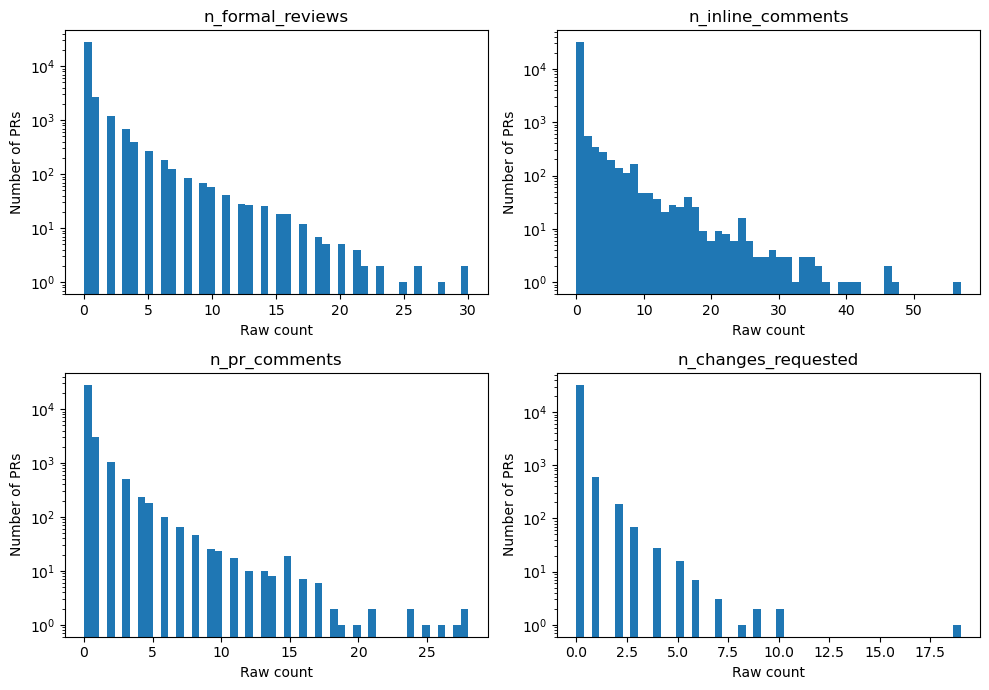

Saved figure to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task1_1_raw_effort_distributions_log_y.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, col in zip(axes, effort_count_cols):
    ax.hist(a3[col], bins=50)
    ax.set_title(col)
    ax.set_xlabel("Raw count")
    ax.set_ylabel("Number of PRs")
    ax.set_yscale("log")

plt.tight_layout()

fig_path = FIG_DIR / "task1_1_raw_effort_distributions_log_y.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure to: {fig_path}")

## 15. Standardize Review-Effort Features for Clustering

This cell prepares the four log-transformed review-effort dimensions for clustering.

Although the variables have already been transformed using `log1p`, they can still have different ranges and variances. Standardization converts each feature to have mean 0 and standard deviation 1.

This step is important for K-Means because K-Means is distance-based. If one feature has a larger numeric scale, it can dominate the distance calculation even if it is not conceptually more important.

In [19]:
from sklearn.preprocessing import StandardScaler

effort_log_cols = [
    "log1p_n_formal_reviews",
    "log1p_n_inline_comments",
    "log1p_n_pr_comments",
    "log1p_n_changes_requested"
]

X_effort = a3[effort_log_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_effort)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=[f"scaled_{col}" for col in effort_log_cols],
    index=a3.index
)

print("Scaled feature summary:")
display(X_scaled_df.describe().T)

Scaled feature summary:


,count,mean,std,min,25%,50%,75%,max
scaled_log1p_n_formal_reviews,33596.0,-6.767879e-17,1.000015,-0.412999,-0.412999,-0.412999,-0.412999,6.463944
scaled_log1p_n_inline_comments,33596.0,-1.082861e-16,1.000015,-0.280245,-0.280245,-0.280245,-0.280245,8.459373
scaled_log1p_n_pr_comments,33596.0,-6.767879e-17,1.000015,-0.388967,-0.388967,-0.388967,-0.388967,7.699014
scaled_log1p_n_changes_requested,33596.0,-2.030364e-17,1.000015,-0.156890,-0.156890,-0.156890,-0.156890,18.918542


## 16. Evaluate Candidate Numbers of Clusters

This cell tests several possible values of `k` for K-Means clustering.

K-Means is used here because the clustering feature space is small, numeric, log-transformed, and standardized. This makes the method simple, reproducible, and easy to interpret in the report.

For each candidate value of `k`, I calculate four internal clustering metrics:

- `inertia`: measures within-cluster compactness. Lower is better.
- `silhouette`: measures how well each PR fits its assigned cluster compared with other clusters. Higher is better.
- `davies_bouldin`: measures cluster separation relative to cluster spread. Lower is better.
- `calinski_harabasz`: measures between-cluster separation relative to within-cluster compactness. Higher is better.

No single metric is enough to choose the best clustering solution. The final choice of `k` will consider both metric quality and whether the resulting clusters are interpretable as meaningful review-effort groups.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

candidate_ks = range(2, 9)
cluster_metrics = []

for k in candidate_ks:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_
    
    sil = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(10000, len(X_scaled)),
        random_state=42
    )
    
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    
    cluster_metrics.append({
        "k": k,
        "inertia": inertia,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch
    })

cluster_metrics_df = pd.DataFrame(cluster_metrics)

metrics_path = TAB_DIR / "task1_2_clustering_metrics.csv"
cluster_metrics_df.to_csv(metrics_path, index=False)

display(cluster_metrics_df)

print(f"Saved clustering metrics to: {metrics_path}")

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,72667.040707,0.813841,0.866901,28531.773282
1,3,51619.844891,0.801997,0.920466,26930.498033
2,4,35711.656877,0.798747,0.827163,30938.556576
3,5,29574.142306,0.837305,0.822831,29761.369690
4,6,25481.786660,0.837976,0.947326,28710.901594
5,7,21926.914633,0.846870,0.946706,28711.449708
6,8,18958.184073,0.858954,0.952539,29214.087251


Saved clustering metrics to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task1_2_clustering_metrics.csv


## 17. Inspect Candidate Cluster Sizes and Centers

The previous cell compared clustering metrics for different values of `k`, but metrics alone are not enough.

This cell fits several candidate K-Means models and summarizes:

1. The size of each cluster.
2. The median raw review-effort values inside each cluster.

This is necessary because an apparently strong metric can still produce clusters that are too small, too fragmented, or difficult to interpret. The final clustering solution should balance metric quality with meaningful review-effort profiles.

In [21]:
candidate_models_to_inspect = [4, 5, 6, 8]

raw_profile_cols = [
    "n_formal_reviews",
    "n_inline_comments",
    "n_pr_comments",
    "n_changes_requested"
]

for k in candidate_models_to_inspect:
    print(f"\n{'='*70}")
    print(f"K-Means candidate: k = {k}")
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    temp = a3.copy()
    temp["cluster"] = labels
    
    size_table = (
        temp["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="n_prs")
    )
    size_table["percent"] = size_table["n_prs"] / len(temp)
    
    print("\nCluster sizes:")
    display(size_table)
    
    profile_table = (
        temp
        .groupby("cluster")[raw_profile_cols]
        .median()
        .reset_index()
    )
    
    print("\nMedian raw effort values by cluster:")
    display(profile_table)


K-Means candidate: k = 4

Cluster sizes:


,cluster,n_prs,percent
0,0,27170,0.808727
1,1,1726,0.051375
2,2,3782,0.112573
3,3,918,0.027325



Median raw effort values by cluster:


,cluster,n_formal_reviews,n_inline_comments,n_pr_comments,n_changes_requested
0,0,0.0,0.0,0.0,0.0
1,1,4.0,3.0,1.0,0.0
2,2,0.0,0.0,1.0,0.0
3,3,3.0,3.0,1.0,1.0



K-Means candidate: k = 5

Cluster sizes:


...

,cluster,n_formal_reviews,n_inline_comments,n_pr_comments,n_changes_requested
0,0,0.0,0.0,0.0,0.0
1,1,5.0,4.0,1.0,0.0
2,2,2.0,1.0,1.0,1.0
3,3,0.0,0.0,1.0,0.0
4,4,1.0,0.0,0.0,0.0
5,5,6.0,9.0,1.0,2.0



K-Means candidate: k = 8

Cluster sizes:


,cluster,n_prs,percent
0,0,2698,0.080307
1,1,24955,0.742797
2,2,529,0.015746
3,3,323,0.009614
4,4,591,0.017591
5,5,1132,0.033694
6,6,1030,0.030658
7,7,2338,0.069592



Median raw effort values by cluster:


,cluster,n_formal_reviews,n_inline_comments,n_pr_comments,n_changes_requested
0,0,0.0,0.0,1.0,0.0
1,1,0.0,0.0,0.0,0.0
2,2,7.0,7.0,3.0,0.0
3,3,6.0,9.0,1.0,2.0
4,4,2.0,1.0,1.0,1.0
5,5,3.0,3.0,0.0,0.0
6,6,1.0,0.0,3.0,0.0
7,7,1.0,0.0,0.0,0.0


## 18. Select Final Clustering Solution

After comparing candidate values of `k`, I select `k = 5` as the final clustering solution.

Although larger values such as `k = 8` produce slightly higher silhouette scores, they split the reviewed PRs into smaller and more fragmented groups. Since the assignment requires interpretable cluster profiles, the final choice should balance internal metrics with meaningful domain interpretation.

The `k = 5` solution provides a strong balance:

- It has a high silhouette score.
- It has a low Davies-Bouldin index compared with other candidates.
- It separates the major review-effort patterns clearly.
- It avoids over-fragmenting the rare high-review PRs too much.

The final five clusters will be used as the ground-truth labels for the text classification task in Part 2.

In [22]:
FINAL_K = 5

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=50
)

a3["cluster_id"] = final_kmeans.fit_predict(X_scaled)

print("Final cluster sizes:")
final_cluster_sizes = (
    a3["cluster_id"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_id")
    .reset_index(name="n_prs")
)

final_cluster_sizes["percent"] = final_cluster_sizes["n_prs"] / len(a3)

display(final_cluster_sizes)

print("\nFinal cluster median raw effort values:")
final_cluster_medians = (
    a3
    .groupby("cluster_id")[raw_profile_cols]
    .median()
    .reset_index()
)

display(final_cluster_medians)

Final cluster sizes:


,cluster_id,n_prs,percent
0,0,24955,0.742797
1,1,918,0.027325
2,2,1332,0.039648
3,3,2846,0.084712
4,4,3545,0.105519



Final cluster median raw effort values:


,cluster_id,n_formal_reviews,n_inline_comments,n_pr_comments,n_changes_requested
0,0,0.0,0.0,0.0,0.0
1,1,3.0,3.0,1.0,1.0
2,2,5.0,4.0,1.0,0.0
3,3,1.0,0.0,0.0,0.0
4,4,0.0,0.0,1.0,0.0


## 19. Assign Interpretable Cluster Labels

This cell assigns human-readable labels to the final clusters.

The original K-Means cluster IDs are arbitrary numbers. To make the results interpretable in the report and usable in the Part 2 classifier, each cluster is renamed based on its median review-effort profile.

The labels describe the dominant review pattern in each cluster, not the agent or task type. Agent identity and task type are reserved for later cluster profiling.

In [23]:
cluster_label_map = {
    0: "No/Low Human Review",
    1: "Correction-Heavy Review",
    2: "High-Activity Code Review",
    3: "Light Formal Review",
    4: "Discussion-Only Review"
}

a3["cluster_label"] = a3["cluster_id"].map(cluster_label_map)

cluster_label_summary = (
    a3
    .groupby(["cluster_id", "cluster_label"])
    .size()
    .reset_index(name="n_prs")
)

cluster_label_summary["percent"] = cluster_label_summary["n_prs"] / len(a3)

display(cluster_label_summary)

,cluster_id,cluster_label,n_prs,percent
0,0,No/Low Human Review,24955,0.742797
1,1,Correction-Heavy Review,918,0.027325
2,2,High-Activity Code Review,1332,0.039648
3,3,Light Formal Review,2846,0.084712
4,4,Discussion-Only Review,3545,0.105519


## 20. Create Final Cluster Effort Profiles

This cell creates the main effort-based cluster profile table.

For each cluster, it reports the number of PRs, the percentage of the dataset, and the median and range of each review-effort dimension. This directly supports the Assignment 3 requirement that each cluster profile include core review-effort statistics.

The median is used because the effort variables are highly skewed. The range is included because the assignment explicitly asks for median and range of each effort dimension.

In [24]:
def value_range(series):
    return f"{series.min()}-{series.max()}"

cluster_effort_profiles = (
    a3
    .groupby(["cluster_id", "cluster_label"])
    .agg(
        n_prs=("id", "count"),
        formal_reviews_median=("n_formal_reviews", "median"),
        formal_reviews_range=("n_formal_reviews", value_range),
        inline_comments_median=("n_inline_comments", "median"),
        inline_comments_range=("n_inline_comments", value_range),
        pr_comments_median=("n_pr_comments", "median"),
        pr_comments_range=("n_pr_comments", value_range),
        changes_requested_median=("n_changes_requested", "median"),
        changes_requested_range=("n_changes_requested", value_range)
    )
    .reset_index()
)

cluster_effort_profiles["percent"] = cluster_effort_profiles["n_prs"] / len(a3)

# Put percent near n_prs
cols = [
    "cluster_id",
    "cluster_label",
    "n_prs",
    "percent",
    "formal_reviews_median",
    "formal_reviews_range",
    "inline_comments_median",
    "inline_comments_range",
    "pr_comments_median",
    "pr_comments_range",
    "changes_requested_median",
    "changes_requested_range"
]

cluster_effort_profiles = cluster_effort_profiles[cols]

profile_path = TAB_DIR / "task1_2_cluster_effort_profiles.csv"
cluster_effort_profiles.to_csv(profile_path, index=False)

display(cluster_effort_profiles)

print(f"Saved cluster effort profiles to: {profile_path}")

,cluster_id,cluster_label,n_prs,percent,formal_reviews_median,formal_reviews_range,inline_comments_median,inline_comments_range,pr_comments_median,pr_comments_range,changes_requested_median,changes_requested_range
0,0,No/Low Human Review,24955,0.742797,0.0,0-0,0.0,0-0,0.0,0-0,0.0,0-0
1,1,Correction-Heavy Review,918,0.027325,3.0,1-28,3.0,0-46,1.0,0-28,1.0,1-19
2,2,High-Activity Code Review,1332,0.039648,5.0,1-30,4.0,1-57,1.0,0-25,0.0,0-0
3,3,Light Formal Review,2846,0.084712,1.0,1-9,0.0,0-4,0.0,0-2,0.0,0-0
4,4,Discussion-Only Review,3545,0.105519,0.0,0-7,0.0,0-2,1.0,1-28,0.0,0-0


Saved cluster effort profiles to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task1_2_cluster_effort_profiles.csv


## 21. Add External Characteristics for Cluster Profiling

The clustering model used only the four review-effort dimensions. However, the assignment also requires each cluster profile to include basic PR statistics that were not used for clustering.

This cell adds external characteristics to support interpretation:

- agent identity,
- task type,
- repository stars,
- programming language,
- merge status.

These variables help explain what kinds of PRs appear in each review-effort cluster, but they are not used to create the clusters.

In [25]:
# Prepare task type table
task_type = tables["pr_task_type"].copy()

task_type_profile = task_type[["id", "type", "confidence"]].copy()
task_type_profile = task_type_profile.rename(columns={
    "type": "task_type",
    "confidence": "task_type_confidence"
})

# Prepare repository metadata table
repo = tables["repository"].copy()

repo_profile = repo[["id", "stars", "language", "forks"]].copy()
repo_profile = repo_profile.rename(columns={
    "id": "repo_id",
    "stars": "repo_stars",
    "language": "repo_language",
    "forks": "repo_forks"
})

# Merge external characteristics into a3
a3_profiled = a3.merge(task_type_profile, on="id", how="left")
a3_profiled = a3_profiled.merge(repo_profile, on="repo_id", how="left")

# Create merge indicator
a3_profiled["is_merged"] = a3_profiled["merged_at"].notna().astype(int)

print(f"Profiled A3 dataframe shape: {a3_profiled.shape}")

print("\nMissing values in external profiling variables:")
display(
    a3_profiled[
        ["task_type", "task_type_confidence", "repo_stars", "repo_language", "repo_forks", "is_merged"]
    ].isna().mean().to_frame("missing_percent")
)

display(a3_profiled[
    ["id", "cluster_id", "cluster_label", "agent", "task_type", "repo_stars", "repo_language", "is_merged"]
].head())

Profiled A3 dataframe shape: (33596, 30)

Missing values in external profiling variables:


,missing_percent
task_type,0.000000
task_type_confidence,0.000000
repo_stars,0.000000
repo_language,0.005447
repo_forks,0.000000
is_merged,0.000000


,id,cluster_id,cluster_label,agent,task_type,repo_stars,repo_language,is_merged
0,3264933329,4,Discussion-Only Review,Claude_Code,fix,1230,Python,0
1,3265118634,0,No/Low Human Review,Claude_Code,refactor,391,TypeScript,1
2,3265640341,3,Light Formal Review,Claude_Code,feat,505,Swift,1
3,3265709660,0,No/Low Human Review,Claude_Code,feat,367,TypeScript,1
4,3265782173,0,No/Low Human Review,Claude_Code,chore,4835,Rust,0


## 22. Summarize External Characteristics by Cluster

This cell creates cluster profile statistics using variables that were not used for clustering.

These external statistics help interpret what each review-effort cluster represents in practice. I summarize:

- dominant AI agent in each cluster,
- dominant PR task type,
- merge rate,
- median repository stars,
- median repository forks,
- dominant repository language.

These variables are only used for interpretation, not for cluster construction.

In [26]:
def dominant_value(series):
    counts = series.dropna().value_counts()
    if counts.empty:
        return "Unknown"
    return counts.index[0]

def dominant_share(series):
    counts = series.dropna().value_counts(normalize=True)
    if counts.empty:
        return 0
    return counts.iloc[0]

cluster_external_profiles = (
    a3_profiled
    .groupby(["cluster_id", "cluster_label"])
    .agg(
        dominant_agent=("agent", dominant_value),
        dominant_agent_share=("agent", dominant_share),
        dominant_task_type=("task_type", dominant_value),
        dominant_task_type_share=("task_type", dominant_share),
        merge_rate=("is_merged", "mean"),
        median_repo_stars=("repo_stars", "median"),
        median_repo_forks=("repo_forks", "median"),
        dominant_language=("repo_language", dominant_value),
        dominant_language_share=("repo_language", dominant_share)
    )
    .reset_index()
)

external_profile_path = TAB_DIR / "task1_2_cluster_external_profiles.csv"
cluster_external_profiles.to_csv(external_profile_path, index=False)

display(cluster_external_profiles)

print(f"Saved external cluster profiles to: {external_profile_path}")

,cluster_id,cluster_label,dominant_agent,dominant_agent_share,dominant_task_type,dominant_task_type_share,merge_rate,median_repo_stars,median_repo_forks,dominant_language,dominant_language_share
0,0,No/Low Human Review,OpenAI_Codex,0.795312,feat,0.453336,0.749589,306.0,43.0,Go,0.379442
1,1,Correction-Heavy Review,Copilot,0.657952,feat,0.431373,0.544662,1216.0,292.0,TypeScript,0.299335
2,2,High-Activity Code Review,Copilot,0.540541,feat,0.417417,0.688438,2464.0,330.0,TypeScript,0.276417
3,3,Light Formal Review,Devin,0.355587,fix,0.330288,0.853830,1373.0,214.0,TypeScript,0.393571
4,4,Discussion-Only Review,Copilot,0.377151,feat,0.372920,0.412130,1666.0,290.0,TypeScript,0.250496


Saved external cluster profiles to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task1_2_cluster_external_profiles.csv


## 23. Create Agent and Task-Type Distribution Tables

The previous table reports only the dominant agent and dominant task type for each cluster. This cell creates more detailed distribution tables.

These tables help identify whether a cluster is strongly associated with a specific agent or task type. They are used only for interpretation and not for clustering.

This is important because the assignment asks for distinguishing characteristics of each cluster. Agent and task-type distributions can help explain what makes one cluster different from another.

In [27]:
agent_distribution = (
    pd.crosstab(
        a3_profiled["cluster_label"],
        a3_profiled["agent"],
        normalize="index"
    )
    .reset_index()
)

task_type_distribution = (
    pd.crosstab(
        a3_profiled["cluster_label"],
        a3_profiled["task_type"],
        normalize="index"
    )
    .reset_index()
)

agent_dist_path = TAB_DIR / "task1_2_agent_distribution_by_cluster.csv"
task_dist_path = TAB_DIR / "task1_2_task_type_distribution_by_cluster.csv"

agent_distribution.to_csv(agent_dist_path, index=False)
task_type_distribution.to_csv(task_dist_path, index=False)

print("Agent distribution by cluster:")
display(agent_distribution)

print("\nTask type distribution by cluster:")
display(task_type_distribution)

print(f"\nSaved agent distribution to: {agent_dist_path}")
print(f"Saved task type distribution to: {task_dist_path}")


Agent distribution by cluster:


agent,cluster_label,Claude_Code,Copilot,Cursor,Devin,OpenAI_Codex
0,Correction-Heavy Review,0.011983,0.657952,0.023965,0.242919,0.063181
1,Discussion-Only Review,0.034979,0.377151,0.068547,0.241185,0.278138
2,High-Activity Code Review,0.026276,0.540541,0.051051,0.275526,0.106607
3,Light Formal Review,0.017920,0.271961,0.085383,0.355587,0.269150
4,No/Low Human Review,0.009537,0.061511,0.038670,0.094971,0.795312



Task type distribution by cluster:


task_type,cluster_label,build,chore,ci,docs,feat,fix,other,perf,refactor,revert,style,test
0,Correction-Heavy Review,0.014161,0.018519,0.011983,0.111111,0.431373,0.309368,0.000000,0.009804,0.055556,0.000000,0.001089,0.037037
1,Discussion-Only Review,0.016643,0.027927,0.007898,0.079831,0.372920,0.371227,0.002539,0.010437,0.069676,0.000846,0.006206,0.033850
2,High-Activity Code Review,0.020270,0.042042,0.008258,0.104354,0.417417,0.252252,0.000751,0.007508,0.105856,0.000000,0.003003,0.038288
3,Light Formal Review,0.018271,0.055517,0.022488,0.139143,0.303233,0.330288,0.000703,0.008082,0.089951,0.001757,0.004568,0.026001
4,No/Low Human Review,0.019074,0.022681,0.011901,0.118894,0.453336,0.209577,0.000761,0.010459,0.063835,0.000321,0.005931,0.083230



Saved agent distribution to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task1_2_agent_distribution_by_cluster.csv
Saved task type distribution to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task1_2_task_type_distribution_by_cluster.csv


## 24. Visualize Clustering Metrics by Number of Clusters

This cell visualizes the internal clustering metrics for different candidate values of `k`.

The goal is to support the choice of the final number of clusters. I compare multiple metrics because no single clustering metric is sufficient. The final decision should balance compactness, separation, and interpretability.

Although larger `k` values can slightly improve some metrics, they may also over-split rare high-review PRs into very small clusters. Therefore, the selected solution is based on both metric quality and whether the resulting clusters have meaningful review-effort profiles.

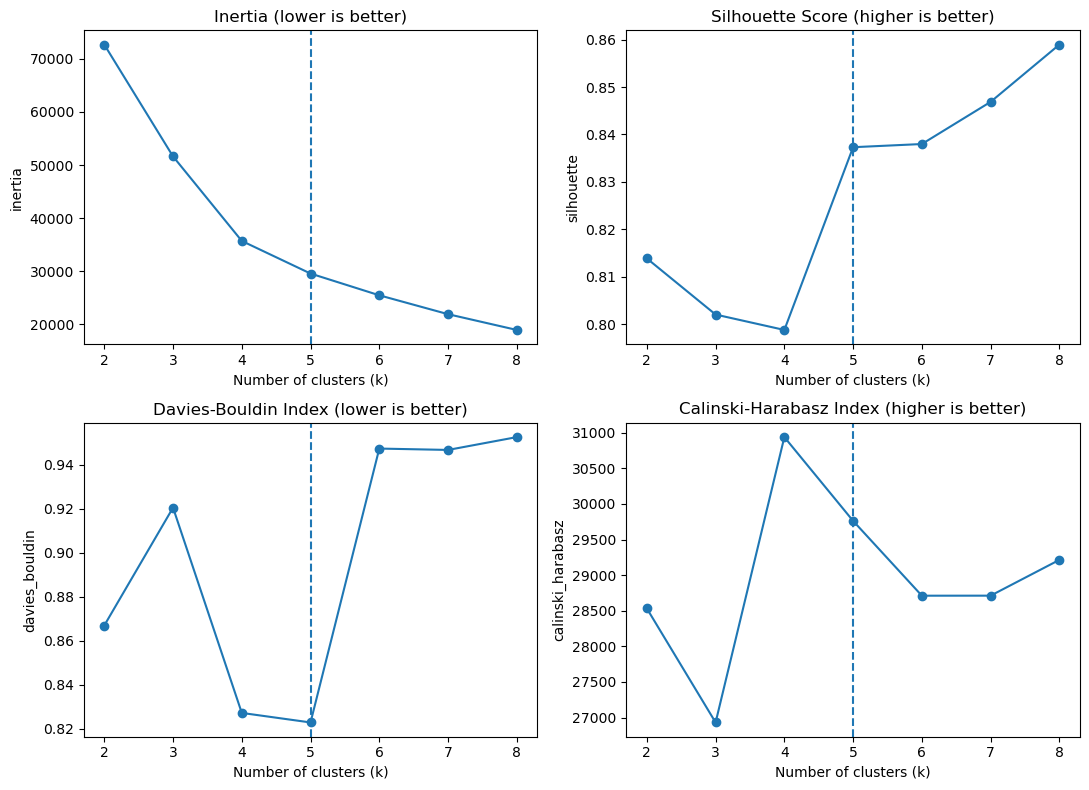

Saved figure to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task1_2_clustering_metrics_by_k.png


In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

metric_specs = [
    ("inertia", "Inertia (lower is better)"),
    ("silhouette", "Silhouette Score (higher is better)"),
    ("davies_bouldin", "Davies-Bouldin Index (lower is better)"),
    ("calinski_harabasz", "Calinski-Harabasz Index (higher is better)")
]

for ax, (metric, title) in zip(axes, metric_specs):
    ax.plot(cluster_metrics_df["k"], cluster_metrics_df[metric], marker="o")
    ax.axvline(FINAL_K, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Number of clusters (k)")
    ax.set_ylabel(metric)

plt.tight_layout()

fig_path = FIG_DIR / "task1_2_clustering_metrics_by_k.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure to: {fig_path}")

## 25. Visualize Final Cluster Sizes

This cell visualizes the size of each final cluster.

Cluster size is important because a clustering solution should not only have good internal metrics; it should also produce groups that are large enough and meaningful enough to interpret. Very small clusters may be valid if they represent rare high-effort cases, but too many tiny clusters can make the solution less useful.

This plot shows that the largest cluster is the No/Low Human Review group, while the more intensive review clusters are smaller but still interpretable.

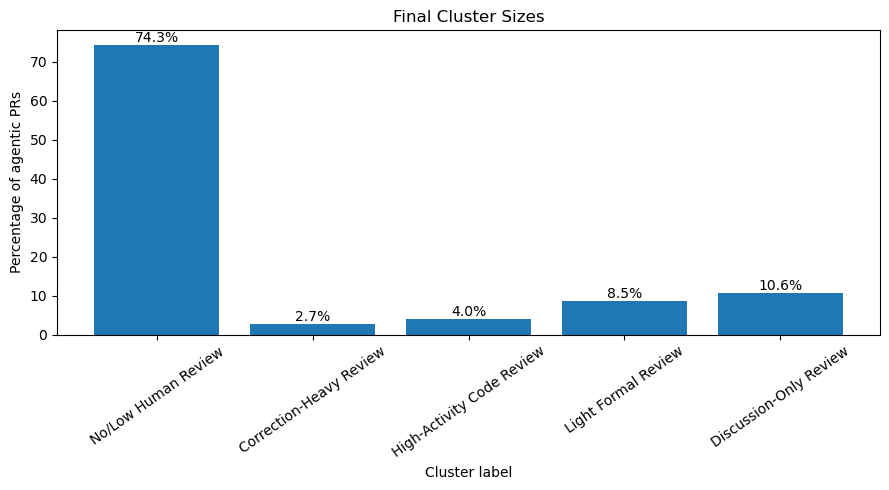

Saved figure to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task1_2_final_cluster_sizes.png


In [29]:
cluster_size_plot = cluster_label_summary.copy()
cluster_size_plot["percent_display"] = cluster_size_plot["percent"] * 100

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    cluster_size_plot["cluster_label"],
    cluster_size_plot["percent_display"]
)

ax.set_title("Final Cluster Sizes")
ax.set_xlabel("Cluster label")
ax.set_ylabel("Percentage of agentic PRs")
ax.tick_params(axis="x", rotation=35)

for i, row in cluster_size_plot.iterrows():
    ax.text(
        i,
        row["percent_display"],
        f"{row['percent_display']:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

fig_path = FIG_DIR / "task1_2_final_cluster_sizes.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure to: {fig_path}")

## 26. Visualize Cluster Review-Effort Profiles

This cell creates a heatmap of the median review-effort dimensions for each cluster.

This is the most important visualization for Task 1.2 because it shows how the clusters differ in terms of the variables actually used for clustering.

The heatmap helps confirm that the five clusters are interpretable:

- No/Low Human Review has zero values across all review-effort dimensions.
- Light Formal Review has formal reviews but little discussion or inline scrutiny.
- Discussion-Only Review has PR-level discussion but little formal or inline review.
- High-Activity Code Review has high formal review and inline comment activity without change requests.
- Correction-Heavy Review includes requested changes and therefore captures rework burden.

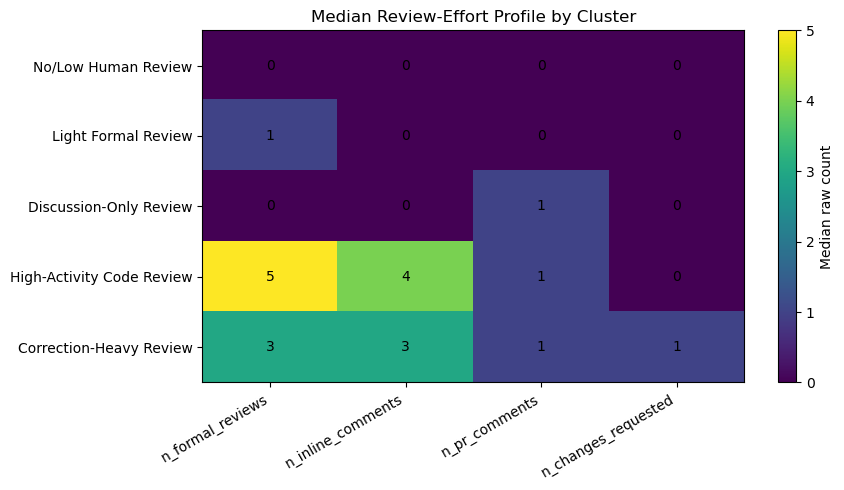

Saved figure to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task1_2_cluster_effort_profile_heatmap.png


In [30]:
profile_heatmap_data = (
    a3
    .groupby("cluster_label")[raw_profile_cols]
    .median()
    .loc[
        [
            "No/Low Human Review",
            "Light Formal Review",
            "Discussion-Only Review",
            "High-Activity Code Review",
            "Correction-Heavy Review"
        ]
    ]
)

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(profile_heatmap_data.values, aspect="auto")

ax.set_xticks(range(len(profile_heatmap_data.columns)))
ax.set_xticklabels(profile_heatmap_data.columns, rotation=30, ha="right")

ax.set_yticks(range(len(profile_heatmap_data.index)))
ax.set_yticklabels(profile_heatmap_data.index)

ax.set_title("Median Review-Effort Profile by Cluster")

for i in range(profile_heatmap_data.shape[0]):
    for j in range(profile_heatmap_data.shape[1]):
        ax.text(
            j,
            i,
            f"{profile_heatmap_data.iloc[i, j]:.0f}",
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax, label="Median raw count")

plt.tight_layout()

fig_path = FIG_DIR / "task1_2_cluster_effort_profile_heatmap.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure to: {fig_path}")

## 27. Visualize Agent Distribution by Cluster

This cell visualizes the distribution of AI agents inside each cluster.

Agent identity was not used to create the clusters, so this plot is an external profiling result. It helps identify whether certain agents are associated with different review-effort patterns.

For example, the No/Low Human Review cluster is dominated by OpenAI Codex, while the correction-heavy and high-activity review clusters are more strongly associated with Copilot.

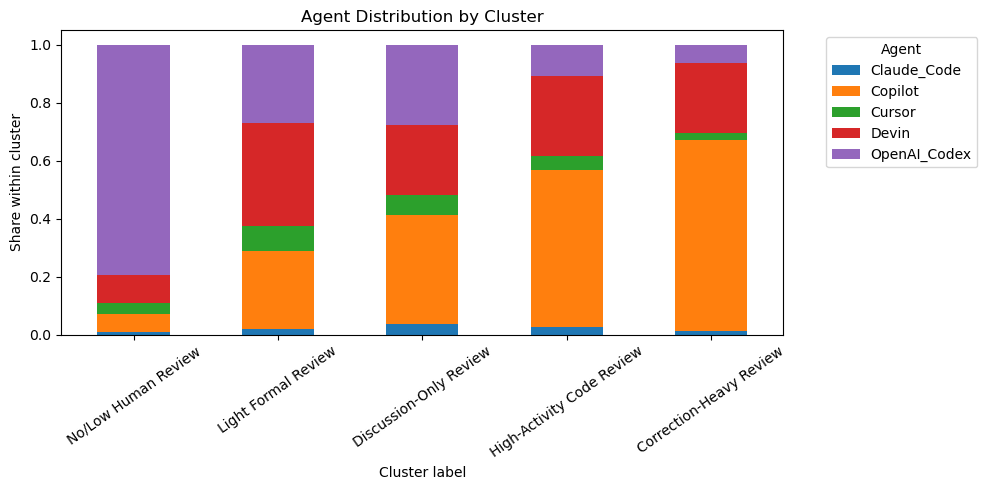

Saved figure to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task1_2_agent_distribution_by_cluster.png


In [31]:
agent_plot = agent_distribution.set_index("cluster_label")

ordered_clusters = [
    "No/Low Human Review",
    "Light Formal Review",
    "Discussion-Only Review",
    "High-Activity Code Review",
    "Correction-Heavy Review"
]

agent_plot = agent_plot.loc[ordered_clusters]

fig, ax = plt.subplots(figsize=(10, 5))

agent_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Agent Distribution by Cluster")
ax.set_xlabel("Cluster label")
ax.set_ylabel("Share within cluster")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Agent", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

fig_path = FIG_DIR / "task1_2_agent_distribution_by_cluster.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure to: {fig_path}")

## 28. Visualize Main Task-Type Distribution by Cluster

This cell visualizes the task-type distribution inside each cluster.

Task type was not used for clustering, so it provides an external characteristic of the clusters. The plot helps show whether certain review-effort groups are associated with feature work, fixes, documentation, refactoring, or tests.

To keep the plot readable, I focus on the most common task types.

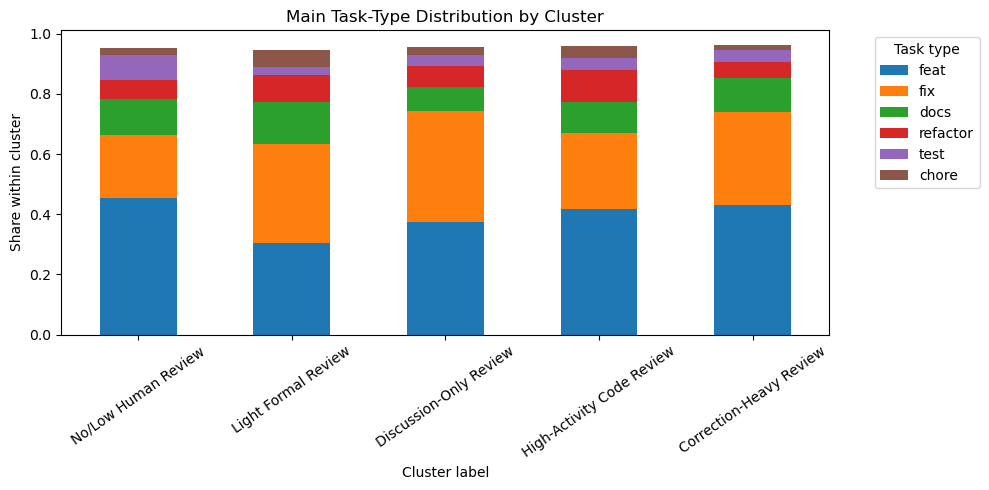

Saved figure to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task1_2_task_type_distribution_by_cluster.png


In [32]:
common_task_types = ["feat", "fix", "docs", "refactor", "test", "chore"]

task_plot = task_type_distribution.set_index("cluster_label")

task_plot_common = task_plot[common_task_types].loc[ordered_clusters]

fig, ax = plt.subplots(figsize=(10, 5))

task_plot_common.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Main Task-Type Distribution by Cluster")
ax.set_xlabel("Cluster label")
ax.set_ylabel("Share within cluster")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Task type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

fig_path = FIG_DIR / "task1_2_task_type_distribution_by_cluster.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure to: {fig_path}")

## 29. Create Compact Final Cluster Profile Table

This cell creates a compact final cluster profile table for the report.

It combines the most important information from the effort profiles and external profiles:

- cluster size,
- median effort dimensions,
- dominant agent,
- dominant task type,
- merge rate,
- median repository stars,
- dominant language.

This table is designed to support the written cluster profiles in the report.

In [33]:
compact_cluster_profiles = cluster_effort_profiles.merge(
    cluster_external_profiles,
    on=["cluster_id", "cluster_label"],
    how="left"
)

compact_cluster_profiles_report = compact_cluster_profiles[
    [
        "cluster_id",
        "cluster_label",
        "n_prs",
        "percent",
        "formal_reviews_median",
        "inline_comments_median",
        "pr_comments_median",
        "changes_requested_median",
        "dominant_agent",
        "dominant_agent_share",
        "dominant_task_type",
        "dominant_task_type_share",
        "merge_rate",
        "median_repo_stars",
        "dominant_language"
    ]
].copy()

compact_cluster_profiles_report["percent"] = compact_cluster_profiles_report["percent"] * 100
compact_cluster_profiles_report["dominant_agent_share"] = compact_cluster_profiles_report["dominant_agent_share"] * 100
compact_cluster_profiles_report["dominant_task_type_share"] = compact_cluster_profiles_report["dominant_task_type_share"] * 100
compact_cluster_profiles_report["merge_rate"] = compact_cluster_profiles_report["merge_rate"] * 100

compact_path = TAB_DIR / "task1_2_compact_cluster_profiles_report.csv"
compact_cluster_profiles_report.to_csv(compact_path, index=False)

display(compact_cluster_profiles_report)

print(f"Saved compact cluster profile table to: {compact_path}")

,cluster_id,cluster_label,n_prs,percent,formal_reviews_median,inline_comments_median,pr_comments_median,changes_requested_median,dominant_agent,dominant_agent_share,dominant_task_type,dominant_task_type_share,merge_rate,median_repo_stars,dominant_language
0,0,No/Low Human Review,24955,74.279676,0.0,0.0,0.0,0.0,OpenAI_Codex,79.531156,feat,45.333600,74.958926,306.0,Go
1,1,Correction-Heavy Review,918,2.732468,3.0,3.0,1.0,1.0,Copilot,65.795207,feat,43.137255,54.466231,1216.0,TypeScript
2,2,High-Activity Code Review,1332,3.964758,5.0,4.0,1.0,0.0,Copilot,54.054054,feat,41.741742,68.843844,2464.0,TypeScript
3,3,Light Formal Review,2846,8.471247,1.0,0.0,0.0,0.0,Devin,35.558679,fix,33.028812,85.382994,1373.0,TypeScript
4,4,Discussion-Only Review,3545,10.551851,0.0,0.0,1.0,0.0,Copilot,37.715092,feat,37.291961,41.212976,1666.0,TypeScript


Saved compact cluster profile table to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task1_2_compact_cluster_profiles_report.csv


## 30. Save Final Clustered Dataset

This cell saves the final Assignment 3 dataset after assigning cluster IDs and cluster labels.

This file will be used in Part 2, where the goal is to predict the discovered review-effort cluster from the PR description text.

Saving the clustered dataset ensures that the classification task uses the exact same labels created in Part 1.

In [34]:
final_clustered_path = PROC_DIR / "agentic_prs_a3_clustered.parquet"

a3_profiled.to_parquet(final_clustered_path, index=False)

print(f"Saved final clustered dataset to:")
print(final_clustered_path)

print("\nFinal columns available:")
print(a3_profiled.columns.tolist())

Saved final clustered dataset to:
C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\data\processed\agentic_prs_a3_clustered.parquet

Final columns available:
['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url', 'n_formal_reviews', 'n_changes_requested', 'n_inline_comments', 'n_pr_comments', 'log1p_n_formal_reviews', 'log1p_n_inline_comments', 'log1p_n_pr_comments', 'log1p_n_changes_requested', 'cluster_id', 'cluster_label', 'task_type', 'task_type_confidence', 'repo_stars', 'repo_language', 'repo_forks', 'is_merged']


# Part 2: Text-Based Label Prediction

Part 2 uses the cluster labels discovered in Part 1 as the ground-truth classes for supervised text classification.

The goal is to test whether the review-effort group of an agentic PR can be predicted from its textual description. This is important because if PR descriptions contain signals about task complexity, scope, or intent, then maintainers may be able to anticipate review effort earlier in the workflow.

The classification input will be PR text, and the target label will be `cluster_label`.

## 31. Build the Text Classification Dataset

This cell creates the dataset for Part 2.

The input text is built from the PR title and body. I use both fields because the title often contains a short task summary, while the body may contain more detailed information about motivation, implementation, or testing.

PRs with empty or missing body text are handled carefully. For Part 1, these PRs were kept because clustering did not use text. For Part 2, text is the model input, so PRs with no usable text must be removed or replaced by title-only text.

Here, I create a combined `pr_text` field from title and body, then remove rows where the combined text is empty.

In [35]:
# Start from the profiled clustered dataset created in Part 1
classification_df = a3_profiled.copy()

# Ensure title and body are strings
classification_df["title"] = classification_df["title"].fillna("").astype(str)
classification_df["body"] = classification_df["body"].fillna("").astype(str)

# Combine title and body into one text field
classification_df["pr_text"] = (
    classification_df["title"].str.strip()
    + "\n\n"
    + classification_df["body"].str.strip()
).str.strip()

# Remove PRs with no usable text
before_rows = len(classification_df)
classification_df = classification_df[classification_df["pr_text"] != ""].copy()
after_rows = len(classification_df)

print(f"Rows before text filtering: {before_rows:,}")
print(f"Rows after text filtering:  {after_rows:,}")
print(f"Rows removed:              {before_rows - after_rows:,}")

print("\nCluster label distribution after text filtering:")
display(
    classification_df["cluster_label"]
    .value_counts()
    .rename_axis("cluster_label")
    .reset_index(name="n_prs")
)

Rows before text filtering: 33,596
Rows after text filtering:  33,596
Rows removed:              0

Cluster label distribution after text filtering:


,cluster_label,n_prs
0,No/Low Human Review,24955
1,Discussion-Only Review,3545
2,Light Formal Review,2846
3,High-Activity Code Review,1332
4,Correction-Heavy Review,918


## 32. Check Class Imbalance

This cell checks the distribution of the target labels before training the classifier.

This is important because the clusters are not balanced. The largest cluster, `No/Low Human Review`, is much bigger than the correction-heavy and high-activity review clusters.

Because of this imbalance, accuracy alone is not a sufficient evaluation metric. The model must be evaluated using per-class precision, recall, and F1-score.

In [36]:
label_distribution = (
    classification_df["cluster_label"]
    .value_counts()
    .rename_axis("cluster_label")
    .reset_index(name="n_prs")
)

label_distribution["percent"] = label_distribution["n_prs"] / len(classification_df) * 100

label_dist_path = TAB_DIR / "task2_label_distribution.csv"
label_distribution.to_csv(label_dist_path, index=False)

display(label_distribution)

print(f"Saved label distribution to: {label_dist_path}")

,cluster_label,n_prs,percent
0,No/Low Human Review,24955,74.279676
1,Discussion-Only Review,3545,10.551851
2,Light Formal Review,2846,8.471247
3,High-Activity Code Review,1332,3.964758
4,Correction-Heavy Review,918,2.732468


Saved label distribution to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task2_label_distribution.csv


## 33. Create Stratified Train/Test Split

This cell splits the classification dataset into training and test sets.

A stratified split is used because the cluster labels are highly imbalanced. Stratification preserves the same approximate class distribution in both training and test sets, which makes evaluation more reliable.

The PR text is the input feature, and the discovered `cluster_label` from Part 1 is the target variable.

In [37]:
from sklearn.model_selection import train_test_split

X_text = classification_df["pr_text"]
y = classification_df["cluster_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size:     {len(X_test):,}")

print("\nTraining label distribution:")
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("cluster_label")
    .reset_index(name="percent")
)

print("\nTest label distribution:")
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("cluster_label")
    .reset_index(name="percent")
)

Training set size: 26,876
Test set size:     6,720

Training label distribution:


,cluster_label,percent
0,No/Low Human Review,74.28
1,Discussion-Only Review,10.55
2,Light Formal Review,8.47
3,High-Activity Code Review,3.97
4,Correction-Heavy Review,2.73



Test label distribution:


,cluster_label,percent
0,No/Low Human Review,74.29
1,Discussion-Only Review,10.55
2,Light Formal Review,8.47
3,High-Activity Code Review,3.96
4,Correction-Heavy Review,2.74


## 34. Train Baseline Text Classifier: TF-IDF + Logistic Regression

This cell trains the first supervised text classification model.

The input is the combined PR title and body text. The target is the review-effort cluster label discovered in Part 1.

I use a TF-IDF representation because it is a strong and interpretable baseline for text classification. TF-IDF gives higher weight to words that are important in a PR description but not common across all PRs.

I use Logistic Regression because it is a standard linear classifier for sparse TF-IDF features. Since the target labels are imbalanced, I set `class_weight="balanced"` so that minority classes such as `Correction-Heavy Review` and `High-Activity Code Review` receive more weight during training.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_logreg_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=50000,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

tfidf_logreg_model.fit(X_train, y_train)

print("TF-IDF + Logistic Regression model trained.")

c:\Users\Administrator\anaconda3\envs\aiddev-a3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


TF-IDF + Logistic Regression model trained.


## 35. Evaluate Baseline Text Classifier

This cell evaluates the TF-IDF + Logistic Regression model on the held-out test set.

Because the target clusters are highly imbalanced, I report more than accuracy:

- Accuracy gives the overall fraction of correct predictions.
- Macro-F1 gives equal weight to every cluster, so it reflects performance on minority classes.
- Weighted-F1 accounts for class size and is useful for overall performance.
- The per-class report shows precision, recall, and F1 for each individual review-effort cluster.

This directly addresses the assignment requirement that accuracy alone is insufficient when clusters are imbalanced.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_tfidf = tfidf_logreg_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_tfidf)
baseline_macro_f1 = f1_score(y_test, y_pred_tfidf, average="macro")
baseline_weighted_f1 = f1_score(y_test, y_pred_tfidf, average="weighted")

print("TF-IDF + Logistic Regression Performance")
print(f"Accuracy:    {baseline_accuracy:.4f}")
print(f"Macro-F1:    {baseline_macro_f1:.4f}")
print(f"Weighted-F1: {baseline_weighted_f1:.4f}")

print("\nPer-class classification report:")
print(classification_report(y_test, y_pred_tfidf, digits=4))

TF-IDF + Logistic Regression Performance
Accuracy:    0.6798
Macro-F1:    0.4238
Weighted-F1: 0.7179

Per-class classification report:
                           precision    recall  f1-score   support

  Correction-Heavy Review     0.2245    0.4185    0.2922       184
   Discussion-Only Review     0.3226    0.4810    0.3862       709
High-Activity Code Review     0.2131    0.3421    0.2626       266
      Light Formal Review     0.2691    0.4218    0.3285       569
      No/Low Human Review     0.9545    0.7650    0.8493      4992

                 accuracy                         0.6798      6720
                macro avg     0.3968    0.4857    0.4238      6720
             weighted avg     0.7805    0.6798    0.7179      6720



## 36. Save Baseline Classification Report

This cell converts the baseline classification report into a table and saves it as a CSV file.

Saving the report is useful because the assignment requires per-class precision, recall, and F1-score for all clusters. The CSV output can be used directly when writing the report.

In [40]:
from sklearn.metrics import classification_report

baseline_report_dict = classification_report(
    y_test,
    y_pred_tfidf,
    digits=4,
    output_dict=True
)

baseline_report_df = pd.DataFrame(baseline_report_dict).T

baseline_report_path = TAB_DIR / "task2_2_baseline_tfidf_logreg_classification_report.csv"
baseline_report_df.to_csv(baseline_report_path)

display(baseline_report_df)

print(f"Saved baseline classification report to: {baseline_report_path}")

,precision,recall,f1-score,support
Correction-Heavy Review,0.224490,0.418478,0.292220,184.000000
Discussion-Only Review,0.322611,0.480959,0.386183,709.000000
High-Activity Code Review,0.213115,0.342105,0.262626,266.000000
Light Formal Review,0.269058,0.421793,0.328542,569.000000
No/Low Human Review,0.954511,0.765024,0.849327,4992.000000
accuracy,0.679762,0.679762,0.679762,0.679762
macro avg,0.396757,0.485672,0.423780,6720.000000
weighted avg,0.780467,0.679762,0.717889,6720.000000


Saved baseline classification report to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task2_2_baseline_tfidf_logreg_classification_report.csv


## 37. Plot Baseline Confusion Matrix

This cell plots the confusion matrix for the TF-IDF + Logistic Regression baseline model.

The confusion matrix shows where the classifier makes mistakes. This is especially important for this assignment because some clusters are much smaller than others. The matrix helps identify whether minority clusters are confused with the majority `No/Low Human Review` class or with each other.

The normalized confusion matrix is used so that each row sums to 1. This makes the results easier to interpret across classes of different sizes.

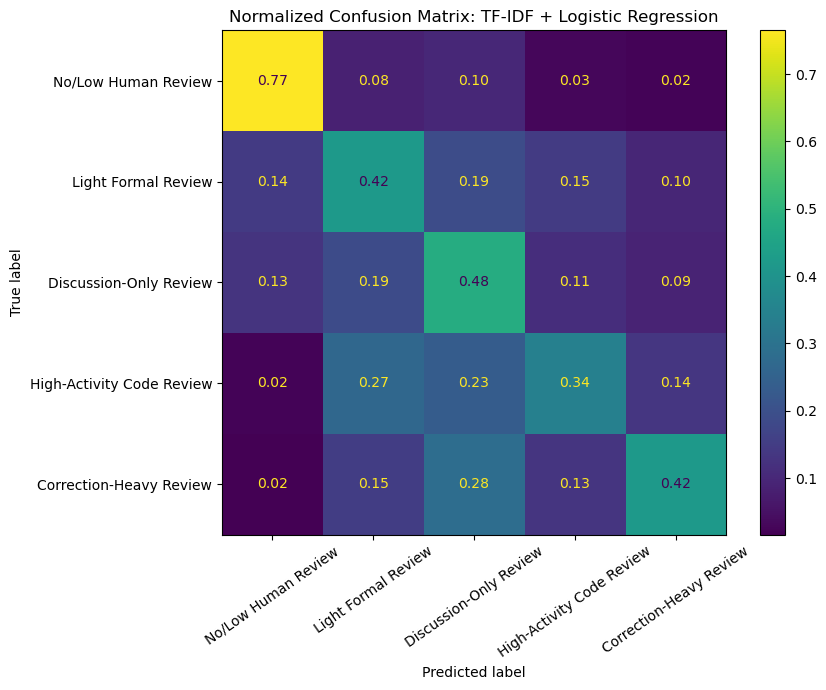

Saved confusion matrix to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task2_2_baseline_tfidf_logreg_confusion_matrix.png


In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

ordered_labels = [
    "No/Low Human Review",
    "Light Formal Review",
    "Discussion-Only Review",
    "High-Activity Code Review",
    "Correction-Heavy Review"
]

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tfidf,
    labels=ordered_labels,
    normalize="true",
    values_format=".2f",
    xticks_rotation=35,
    ax=ax
)

ax.set_title("Normalized Confusion Matrix: TF-IDF + Logistic Regression")

plt.tight_layout()

fig_path = FIG_DIR / "task2_2_baseline_tfidf_logreg_confusion_matrix.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved confusion matrix to: {fig_path}")

## 38. Train Alternative Text Classifier: TF-IDF + Linear SVM

This cell trains a second text classification model using the same TF-IDF representation but a Linear Support Vector Classifier.

Linear SVM is a strong classical baseline for high-dimensional sparse text data. It often performs well when the input is TF-IDF features. Like the logistic regression model, it uses `class_weight="balanced"` to reduce the effect of label imbalance.

The purpose of this model is to test whether a different classifier improves macro-F1 and minority-class performance.

In [42]:
from sklearn.svm import LinearSVC

tfidf_svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=50000,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90
        )
    ),
    (
        "clf",
        LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=5000
        )
    )
])

tfidf_svm_model.fit(X_train, y_train)

print("TF-IDF + Linear SVM model trained.")

TF-IDF + Linear SVM model trained.


## 39. Evaluate TF-IDF + Linear SVM

This cell evaluates the Linear SVM model on the same held-out test set.

The same metrics are reported as before: accuracy, macro-F1, weighted-F1, and per-class precision, recall, and F1. This allows a fair comparison with the Logistic Regression baseline.

In [43]:
y_pred_svm = tfidf_svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_macro_f1 = f1_score(y_test, y_pred_svm, average="macro")
svm_weighted_f1 = f1_score(y_test, y_pred_svm, average="weighted")

print("TF-IDF + Linear SVM Performance")
print(f"Accuracy:    {svm_accuracy:.4f}")
print(f"Macro-F1:    {svm_macro_f1:.4f}")
print(f"Weighted-F1: {svm_weighted_f1:.4f}")

print("\nPer-class classification report:")
print(classification_report(y_test, y_pred_svm, digits=4))

TF-IDF + Linear SVM Performance
Accuracy:    0.7391
Macro-F1:    0.4284
Weighted-F1: 0.7469

Per-class classification report:
                           precision    recall  f1-score   support

  Correction-Heavy Review     0.2477    0.2880    0.2663       184
   Discussion-Only Review     0.3736    0.4231    0.3968       709
High-Activity Code Review     0.2386    0.2556    0.2468       266
      Light Formal Review     0.3312    0.3603    0.3451       569
      No/Low Human Review     0.9046    0.8696    0.8867      4992

                 accuracy                         0.7391      6720
                macro avg     0.4191    0.4393    0.4284      6720
             weighted avg     0.7556    0.7391    0.7469      6720



## 40. Save Linear SVM Classification Report

This cell saves the Linear SVM classification report as a table.

The Linear SVM model is currently the strongest classical text classifier because it improves accuracy, weighted-F1, and macro-F1 compared with Logistic Regression.

The report includes precision, recall, and F1-score for every cluster, which is required because the target labels are imbalanced.

In [44]:
svm_report_dict = classification_report(
    y_test,
    y_pred_svm,
    digits=4,
    output_dict=True
)

svm_report_df = pd.DataFrame(svm_report_dict).T

svm_report_path = TAB_DIR / "task2_2_tfidf_svm_classification_report.csv"
svm_report_df.to_csv(svm_report_path)

display(svm_report_df)

print(f"Saved Linear SVM classification report to: {svm_report_path}")

,precision,recall,f1-score,support
Correction-Heavy Review,0.247664,0.288043,0.266332,184.000000
Discussion-Only Review,0.373599,0.423131,0.396825,709.000000
High-Activity Code Review,0.238596,0.255639,0.246824,266.000000
Light Formal Review,0.331179,0.360281,0.345118,569.000000
No/Low Human Review,0.904563,0.869591,0.886733,4992.000000
accuracy,0.739137,0.739137,0.739137,0.739137
macro avg,0.419120,0.439337,0.428366,6720.000000
weighted avg,0.755646,0.739137,0.746868,6720.000000


Saved Linear SVM classification report to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task2_2_tfidf_svm_classification_report.csv


## 41. Plot Linear SVM Confusion Matrix

This cell plots the normalized confusion matrix for the Linear SVM model.

The confusion matrix shows which effort groups are easier or harder to predict from PR text. Since the rows are normalized, each row shows the proportion of true examples from that class that were predicted as each label.

This helps with the error analysis in Task 2.3.

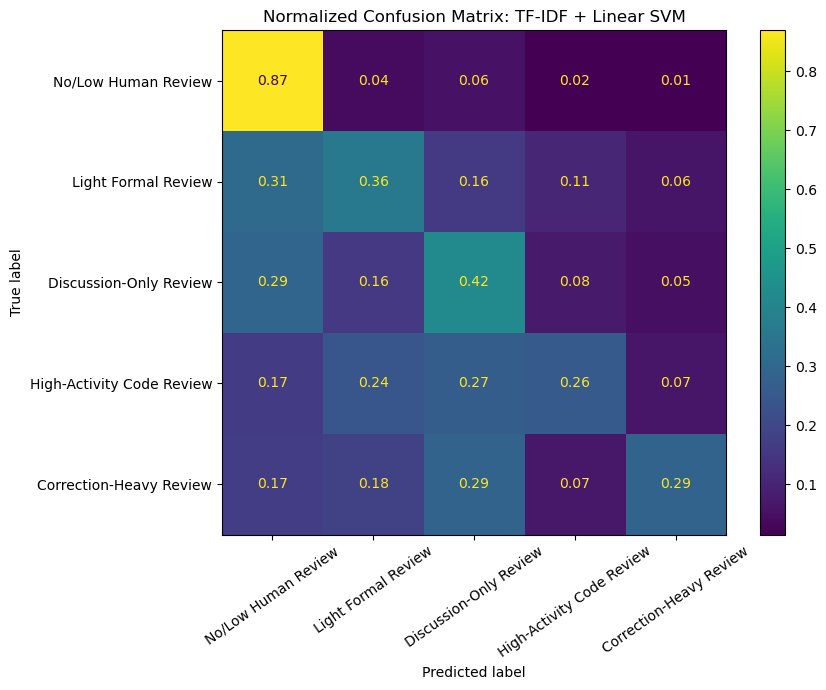

Saved confusion matrix to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task2_2_tfidf_svm_confusion_matrix.png


In [45]:
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    labels=ordered_labels,
    normalize="true",
    values_format=".2f",
    xticks_rotation=35,
    ax=ax
)

ax.set_title("Normalized Confusion Matrix: TF-IDF + Linear SVM")

plt.tight_layout()

fig_path = FIG_DIR / "task2_2_tfidf_svm_confusion_matrix.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved confusion matrix to: {fig_path}")

## 42. Compare Baseline Text Classification Models

This cell compares the two classical text classification models trained so far:

1. TF-IDF + Logistic Regression
2. TF-IDF + Linear SVM

The comparison uses accuracy, macro-F1, and weighted-F1. Macro-F1 is especially important because the classes are imbalanced and we do not want the majority class to dominate the evaluation.

In [46]:
model_comparison = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "accuracy": baseline_accuracy,
        "macro_f1": baseline_macro_f1,
        "weighted_f1": baseline_weighted_f1
    },
    {
        "model": "TF-IDF + Linear SVM",
        "accuracy": svm_accuracy,
        "macro_f1": svm_macro_f1,
        "weighted_f1": svm_weighted_f1
    }
])

model_comparison_path = TAB_DIR / "task2_2_model_comparison.csv"
model_comparison.to_csv(model_comparison_path, index=False)

display(model_comparison)

print(f"Saved model comparison to: {model_comparison_path}")

,model,accuracy,macro_f1,weighted_f1
0,TF-IDF + Logistic Regression,0.679762,0.423780,0.717889
1,TF-IDF + Linear SVM,0.739137,0.428366,0.746868


Saved model comparison to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task2_2_model_comparison.csv


## 43. Final Model Decision

I considered using SentenceTransformer embeddings as a stronger semantic text representation. However, generating embeddings for more than 33k PR descriptions was too slow in the available runtime environment.

To keep the replication package practical and reproducible, I select the best successfully executed model: TF-IDF + Linear SVM.

This model is lightweight, reproducible, and achieved the best performance among the completed models, with higher accuracy and weighted-F1 than TF-IDF + Logistic Regression.

In [47]:
final_model_name = "TF-IDF + Linear SVM"
y_pred_final = y_pred_svm

final_accuracy = svm_accuracy
final_macro_f1 = svm_macro_f1
final_weighted_f1 = svm_weighted_f1

print(f"Final selected model: {final_model_name}")
print(f"Accuracy:    {final_accuracy:.4f}")
print(f"Macro-F1:    {final_macro_f1:.4f}")
print(f"Weighted-F1: {final_weighted_f1:.4f}")

Final selected model: TF-IDF + Linear SVM
Accuracy:    0.7391
Macro-F1:    0.4284
Weighted-F1: 0.7469


## 44. Save Final Model Classification Report

This cell saves the classification report for the final selected model.

The final model is TF-IDF + Linear SVM. The report includes precision, recall, and F1-score for every cluster, which is required because the target labels are highly imbalanced.

In [48]:
final_report_dict = classification_report(
    y_test,
    y_pred_final,
    digits=4,
    output_dict=True
)

final_report_df = pd.DataFrame(final_report_dict).T

final_report_path = TAB_DIR / "task2_2_final_tfidf_svm_classification_report.csv"
final_report_df.to_csv(final_report_path)

display(final_report_df)

print(f"Saved final classification report to: {final_report_path}")

,precision,recall,f1-score,support
Correction-Heavy Review,0.247664,0.288043,0.266332,184.000000
Discussion-Only Review,0.373599,0.423131,0.396825,709.000000
High-Activity Code Review,0.238596,0.255639,0.246824,266.000000
Light Formal Review,0.331179,0.360281,0.345118,569.000000
No/Low Human Review,0.904563,0.869591,0.886733,4992.000000
accuracy,0.739137,0.739137,0.739137,0.739137
macro avg,0.419120,0.439337,0.428366,6720.000000
weighted avg,0.755646,0.739137,0.746868,6720.000000


Saved final classification report to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task2_2_final_tfidf_svm_classification_report.csv


## 45. Plot Final Model Confusion Matrix

This cell plots the normalized confusion matrix for the final TF-IDF + Linear SVM model.

The confusion matrix is important for Task 2.3 because it shows which review-effort clusters are confused with each other. Since the classes are imbalanced, the matrix is normalized by true label so that each row can be interpreted as the recall pattern for that class.

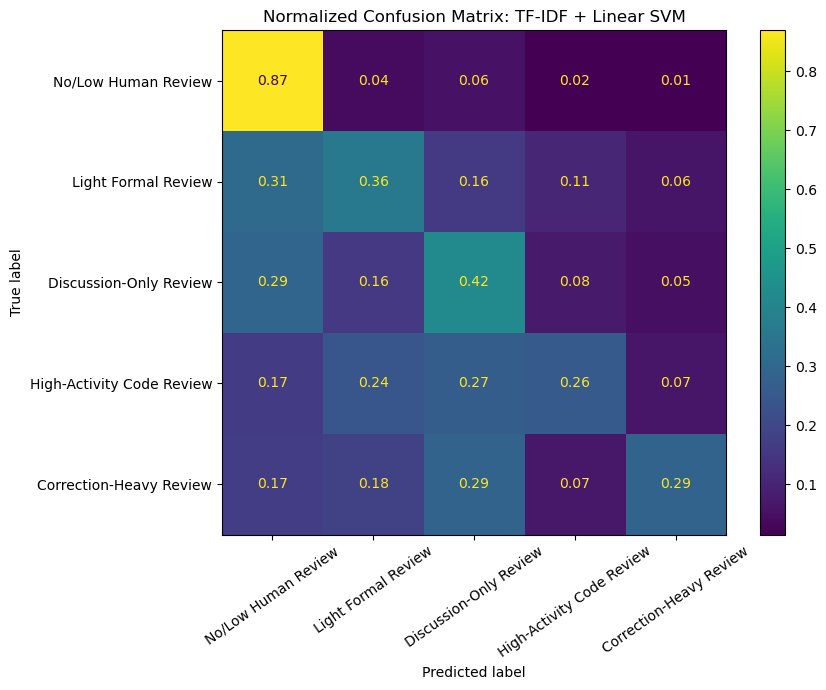

Saved final confusion matrix to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\figures\task2_2_final_tfidf_svm_confusion_matrix.png


In [49]:
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    labels=ordered_labels,
    normalize="true",
    values_format=".2f",
    xticks_rotation=35,
    ax=ax
)

ax.set_title("Normalized Confusion Matrix: TF-IDF + Linear SVM")

plt.tight_layout()

fig_path = FIG_DIR / "task2_2_final_tfidf_svm_confusion_matrix.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved final confusion matrix to: {fig_path}")

## 46. Compare Completed Text Classification Models

This cell compares the completed text classification models.

The comparison includes TF-IDF + Logistic Regression and TF-IDF + Linear SVM. Sentence embeddings were considered but not included in the final comparison because embedding generation was too slow for the available runtime.

Macro-F1 is the most important metric because the cluster labels are highly imbalanced.

In [50]:
model_comparison = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "accuracy": baseline_accuracy,
        "macro_f1": baseline_macro_f1,
        "weighted_f1": baseline_weighted_f1
    },
    {
        "model": "TF-IDF + Linear SVM",
        "accuracy": svm_accuracy,
        "macro_f1": svm_macro_f1,
        "weighted_f1": svm_weighted_f1
    }
])

model_comparison_path = TAB_DIR / "task2_2_model_comparison.csv"
model_comparison.to_csv(model_comparison_path, index=False)

display(model_comparison)

print(f"Saved model comparison to: {model_comparison_path}")

,model,accuracy,macro_f1,weighted_f1
0,TF-IDF + Logistic Regression,0.679762,0.423780,0.717889
1,TF-IDF + Linear SVM,0.739137,0.428366,0.746868


Saved model comparison to: C:\Users\Administrator\OneDrive - Queen's University\cisc839_adv_data_analytics\assignments\assignment 3\submission\A3_Replication_Amrya_Hana\outputs\tables\task2_2_model_comparison.csv
